In [22]:


from CADETProcess.optimization import OptimizationProblem
from CADETProcess.processModel import Inlet, MCT, Outlet, Cstr, TubularReactor
from CADETProcess.optimization import SLSQP, U_NSGA3, Pathos, Joblib, COBYLA, TrustConstr
from CADETProcess.processModel import ComponentSystem,MassActionLaw, LumpedRateModelWithoutPores
from CADETProcess.processModel import FlowSheet
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet
from scipy.optimize import minimize


import logging

from IPython import display

from utils import *

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

In [23]:
df_up = pd.read_excel('2022-11-09-poplar-branch_up.xlsx')
data_up = df_up.to_numpy()
xi_up = df_up.columns.values[1:]
xi_up = [float(x) for x in xi_up]

df_side = pd.read_excel('2022-11-09-poplar-branch_side.xlsx')
data_side = df_side.to_numpy()
xi_side = df_side.columns.values[1:4]
xi_side = [float(x) for x in xi_side]

df_low = pd.read_excel('2022-11-09-poplar-branch_low.xlsx')
data_low = df_low.to_numpy()
xi_low = df_low.columns.values[1:4]
xi_low = [float(x) for x in xi_low]

t = data_up[0:,0]

In [24]:
orig_exp_data_up = data_up[0:,1:]
exp_data_up = data_up[0:,1:]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))

orig_exp_data_side = data_side[0:,1:4]
exp_data_side = data_side[0:,1:4]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))

orig_exp_data_low = data_low[0:,1:4]
exp_data_low = data_low[0:,1:4]*np.exp(-0.00056729782996132*60*t.reshape(len(t),1))


overall_max = max(np.max(exp_data_up),np.max(exp_data_side),np.max(exp_data_low))

exp_data_up = exp_data_up/overall_max
exp_data_side = exp_data_side/overall_max
exp_data_low = exp_data_low/overall_max


exp_data = np.hstack((exp_data_up,exp_data_side,exp_data_low))

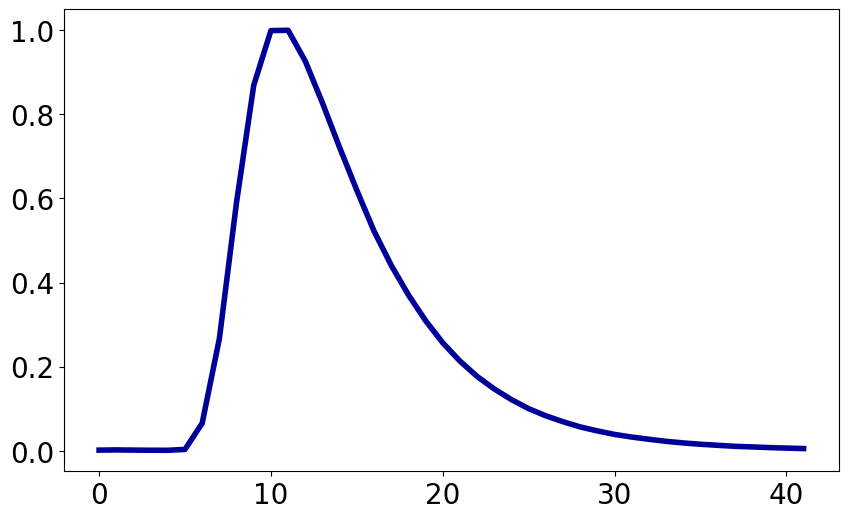

In [25]:
plt.plot(exp_data_up[:,-1]/np.max(exp_data_up[:,-1]))
#plt.plot(exp_data_side/np.max(exp_data_side))

In [26]:
exp_data.shape

(42, 9)

In [27]:
weights = 1# / np.mean(exp_data, axis=0)

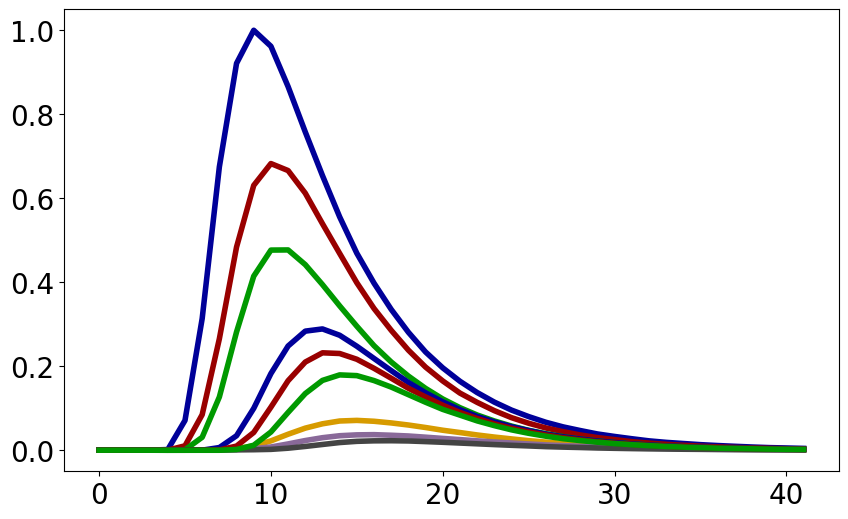

In [28]:
plt.plot(exp_data)

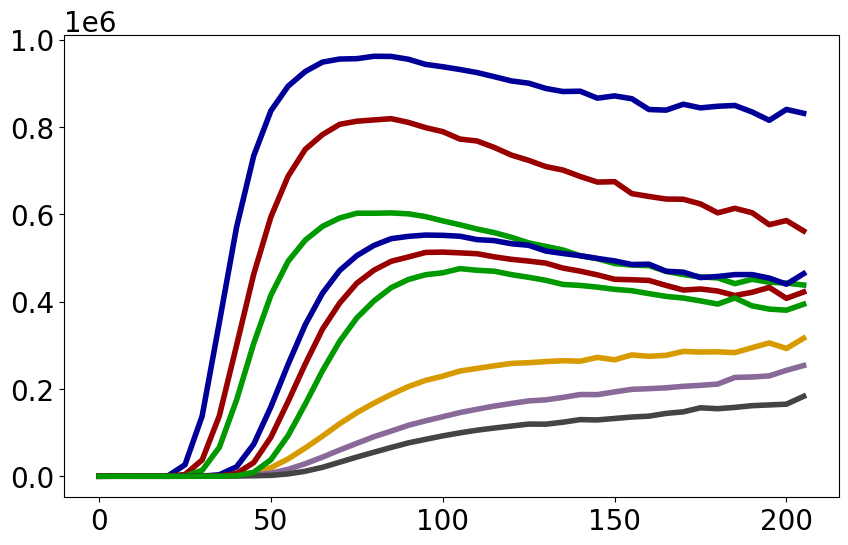

In [30]:
plt.plot(t,orig_exp_data_up)
plt.plot(t,orig_exp_data_side)
plt.plot(t,orig_exp_data_low)

In [10]:
def setup_process(x):
    
    p_volumetric_flow_rate_const = x[0]
    p_mct_up_e12 = x[1]
    p_mct_side1_e12 = x[2]
    p_mct_side2_e12 = x[3]
    p_mct_low_e12 = x[4]
    branch_point_side_quotia = x[5]
    bp_side_porosity = x[6]
    bp_side_branch_len = x[7]
    bp_low_branch_len = x[8]
    p_col_dispersion = x[9]
    p_col_len = x[10]
    p_mct_low_disp = x[11]
    p_mct_up_e21 = x[12]
    p_mct_up_e23 = x[13]


    
  # Initialize the component system and flow sheet
    component_system = ComponentSystem(1)
    mct_flow_sheet = FlowSheet(component_system)

    # Create the units
    inlet = Inlet(component_system, name='inlet')
    leaf = LumpedRateModelWithoutPores(component_system, name='leaf')
    mct_up = MCT(component_system, nchannel=3, name='mct1')
    mct_side1 = MCT(component_system, nchannel=2, name='mct2')
    mct_side2 = MCT(component_system, nchannel=2, name='mct3')
    mct_low = MCT(component_system, nchannel=2, name='mct4')
    branch_point_side = Cstr(component_system, name='bp_side')
    branch_mct_low= MCT(component_system, nchannel=2, name='bp_mct_low')
    branch_mct_side= MCT(component_system, nchannel=1, name='bp_mct_side')
    outlet_side = Outlet(component_system, name='outlet_side')
    outlet_low = Outlet(component_system, name='outlet_low')

    leaf.discretization.ncol = 20
    mct_up.discretization.ncol = 20
    mct_side1.discretization.ncol = 20
    mct_side2.discretization.ncol = 20
    mct_low.discretization.ncol = 20
    branch_mct_low.discretization.ncol = 10
    branch_mct_side.discretization.ncol = 10

    reaction_system = MassActionLaw(component_system)
    reaction_system.add_reaction(
    indices=[0],
    coefficients=[-1],
    k_fwd=0.00056729782996132,
    k_bwd=0,)
    
    mct_up.bulk_reaction_model = reaction_system
    mct_side1.bulk_reaction_model = reaction_system
    mct_side2.bulk_reaction_model = reaction_system
    mct_low.bulk_reaction_model = reaction_system
    branch_point_side.bulk_reaction_model = reaction_system
    branch_mct_side.bulk_reaction_model = reaction_system
    branch_mct_low.bulk_reaction_model = reaction_system


    mct_flow_sheet.add_unit(inlet)
    mct_flow_sheet.add_unit(leaf)
    mct_flow_sheet.add_unit(mct_up)
    mct_flow_sheet.add_unit(mct_side1)
    mct_flow_sheet.add_unit(mct_side2)
    mct_flow_sheet.add_unit(mct_low)
    mct_flow_sheet.add_unit(branch_point_side)
    mct_flow_sheet.add_unit(branch_mct_side)
    mct_flow_sheet.add_unit(branch_mct_low)
    mct_flow_sheet.add_unit(outlet_side)
    mct_flow_sheet.add_unit(outlet_low)

    v_lrmp = 2.5e-05

    leaf.total_porosity = 1
    leaf.length = p_col_len
    leaf.diameter = x[0]/v_lrmp 
    leaf.axial_dispersion = p_col_dispersion

    mct_flow_sheet.add_connection(inlet, leaf)
    mct_flow_sheet.add_connection(leaf, mct_up, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct_up, branch_point_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(mct_up, branch_mct_low, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_mct_low, mct_low, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_point_side, branch_mct_side, destination_port = 'channel_0')
    mct_flow_sheet.add_connection(branch_mct_side, mct_side1, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct_side1, mct_side2, origin_port = 'channel_0', destination_port = 'channel_0')
    mct_flow_sheet.add_connection(mct_side2, outlet_side, origin_port = 'channel_0')
    mct_flow_sheet.add_connection(mct_low, outlet_low, origin_port = 'channel_0')

    mct_flow_sheet.set_output_state(mct_up, [branch_point_side_quotia, 1-branch_point_side_quotia], 'channel_0')

    process = Process(mct_flow_sheet, 'Tracer_Transport')

    mct_up.length =  xi_up[-1]/1000
    mct_side1.length =  xi_side[1]/1000
    mct_side2.length =  xi_side[-1]/1000-xi_side[1]/1000
    mct_low.length =  xi_low[-1]/1000
    branch_mct_low.length = bp_low_branch_len
    branch_mct_side.length = bp_side_branch_len
      
    mct_up.channel_cross_section_areas = [1,1,1] 
    mct_side1.channel_cross_section_areas = [1,1] 
    mct_side2.channel_cross_section_areas = [1,1] 
    mct_low.channel_cross_section_areas = [1,1] 
    branch_mct_low.channel_cross_section_areas = [1,1]
    branch_mct_side.channel_cross_section_areas = [1]

    
    mct_up.axial_dispersion = 0
    mct_side1.axial_dispersion = 0
    mct_side2.axial_dispersion = 0
    mct_low.axial_dispersion = p_mct_low_disp
    branch_mct_side.axial_dispersion = 0
    branch_mct_low.axial_dispersion = 0


    total_volume = 2
    total_porosity_side = bp_side_porosity

    branch_point_side.init_liquid_volume = total_porosity_side * total_volume

    branch_point_side.const_solid_volume = (1 - total_porosity_side) * total_volume

    
    mct_up.solution_recorder.write_solution_bulk = 1
    mct_side1.solution_recorder.write_solution_bulk = 1
    mct_side2.solution_recorder.write_solution_bulk = 1
    mct_low.solution_recorder.write_solution_bulk = 1
    


    mct_up.exchange_matrix = np.array([
                                    [[0.0], [p_mct_up_e12], [0.0]],
                                    [[p_mct_up_e21], [0.0],[p_mct_up_e23]],
                                    [[0.0], [0.0],[0.0]],
                                   
                                    ])
    
    mct_side1.exchange_matrix =np.array([
                                    [[0.0], [p_mct_side1_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    mct_side2.exchange_matrix =np.array([
                                    [[0.0], [p_mct_side2_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    mct_low.exchange_matrix =np.array([
                                    [[0.0], [p_mct_low_e12]],
                                    [[0.0], [0.0]],
                                   
                                    ])

    branch_mct_low.exchange_matrix =np.array([
                                    [[0.0], [0.0]],
                                    [[0.0], [0.0]],
                                   
                                    ])
    
    branch_mct_side.exchange_matrix = np.array([[[0.0]]])

    p_t0= 1.19383418


    process.cycle_time = 60*t[-1]

    inlet.flow_rate = [p_volumetric_flow_rate_const, 0, 0, 0]

    _ = process.add_event('Base', 'flow_sheet.inlet.c', [0], 0)
    _ = process.add_event('Start', 'flow_sheet.inlet.c', [100], p_t0*600)
    _ = process.add_event('Stop', 'flow_sheet.inlet.c', [0], p_t0*600+60)
    
    return process

In [11]:
xi_side

[0.0, 17.894, 38.087]

In [12]:
# Define min and max values for each parameter

param_bounds = {
    'q_const': (5e-05, 1.5e-04),  # log-scaling
    'mct1_e12': (1e-08, 10),                      # log-scaling
    'mct5_e12': (1e-08, 10),                      # log-scaling
    'mct6_e12': (1e-08, 10),                      # log-scaling
    'mct4_e12': (1e-12, 1e-4),                          # log-scaling
    'bp_side_quotia': (0.01, 1),         # linear scaling
    'bp_side_porosity': (1e-3, 1),           # log-scaling
    'bp_side_branch_len': (1e-5, 1), 
    'bp_low_branch_len': (1e-5, 1),                      # log-scaling
    'col_dispersion': (1e-10, 1e-07),                # log-scaling
    'col_len': (0.0005, 0.2),                         # linear scaling
    'low_dispersion': (1e-8, 1e-05),
    'mct1_e21': (1e-08, 10),
    'mct1_e23': (1e-08, 10),

}



def normalize_parameters(x):
    normalized_x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # If the range is large, use log scaling
            norm_param = (np.log(x[i]) - np.log(min_val)) / (np.log(max_val) - np.log(min_val))
        else:  # For compact ranges, use min-max scaling
            norm_param = (x[i] - min_val) / (max_val - min_val)
        
        normalized_x.append(norm_param)
    
    return np.array(normalized_x)

def denormalize_parameters(norm_x):
    x = []
    for i, param in enumerate(param_bounds):
        min_val, max_val = param_bounds[param]
        
        if min_val > 0 and (max_val / min_val) > 100:  # Log scaling for large ranges
            param_value = np.exp(norm_x[i] * (np.log(max_val) - np.log(min_val)) + np.log(min_val))
        else:  # Min-max scaling for compact ranges
            param_value = norm_x[i] * (max_val - min_val) + min_val
        
        x.append(param_value)
    
    return np.array(x)

def analyze_parameters(norm_param_values, param_bounds=param_bounds):
    """
    Analyze parameters and print their names, denormalized values, and normalized values.

    Args:
        norm_param_values (list): Normalized parameter values (0-1 range).
        param_bounds (dict): Dictionary with parameter names as keys and boundary tuples as values.

    Returns:
        None: Prints the analysis.
    """
    print(f"{'Name':<30}{'Denormalized Value':<20}{'Normalized Value':<10}")
    print("-" * 65)

    # Denormalize parameters
    param_values = denormalize_parameters(norm_param_values)

    for i, (name, bounds) in enumerate(param_bounds.items()):
        value = param_values[i]
        norm_param = norm_param_values[i]

        print(f"{name:<30}{value:<20.8e}{norm_param:<10.2f}")

In [13]:
xi_up, xi_side, xi_low

([0.0, 18.069, 36.256], [0.0, 17.894, 38.087], [0.0, 17.272, 34.54])

In [14]:
lenghts_up = [x / 1000 for x in xi_up]
lenghts_side = [x / 1000 for x in xi_side]
lenghts_low = [x / 1000 for x in xi_low]

eval_location1 = lenghts_up
eval_location2 = lenghts_side
eval_location3 = lenghts_low




eval_location1,eval_location2, eval_location3

([0.0, 0.018068999999999998, 0.036256000000000004],
 [0.0, 0.017893999999999997, 0.038087],
 [0.0, 0.017272, 0.03454])

In [15]:
    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2_1 = lenghts_side[0:1]
    eval_location2_2 = list(np.array(lenghts_side[1:])-lenghts_side[1])
    eval_location3 = lenghts_low

In [16]:
lenghts_up, lenghts_side, lenghts_low

([0.0, 0.018068999999999998, 0.036256000000000004],
 [0.0, 0.017893999999999997, 0.038087],
 [0.0, 0.017272, 0.03454])

In [17]:
eval_location1, eval_location2_1, eval_location2_2, eval_location3

([0.0, 0.018068999999999998, 0.036256000000000004],
 [0.0],
 [np.float64(0.0), np.float64(0.020193000000000006)],
 [0.0, 0.017272, 0.03454])

In [25]:
def mct_obj(x_norm):
    x = denormalize_parameters(x_norm)
    process = setup_process(x)
    simulation_results = simulator.simulate(process)
    time_new = np.arange(t[0]*60, t[-1]*60 + 5*60, 5*60)

    mct_up = process.flow_sheet.units[2]
    mct_side1 = process.flow_sheet.units[3]
    mct_side2 = process.flow_sheet.units[4]
    mct_low = process.flow_sheet.units[5]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2_1 = lenghts_side[0:1]
    eval_location2_2 = list(np.array(lenghts_side[1:]) - lenghts_side[1])
    eval_location3 = lenghts_low

    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct_up, time_new, axial_positions_new=eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()

    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct_side1, time_new, axial_positions_new=eval_location2_1)
    calc_data_mct2 = np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct_side2, time_new, axial_positions_new=eval_location2_2)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct_low, time_new, axial_positions_new=eval_location3)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()

    # Combine all simulated data
    calc_data = np.hstack((calc_data_mct1, calc_data_mct2, calc_data_mct3, calc_data_mct4))
    calc_data = calc_data / np.max(calc_data)

    # Split experimental data accordingly
    len1 = calc_data_mct1.shape[1] if calc_data_mct1.ndim > 1 else 1
    len2 = calc_data_mct2.shape[1] if calc_data_mct2.ndim > 1 else 1
    len3 = calc_data_mct3.shape[1] if calc_data_mct3.ndim > 1 else 1



    w1 =  1/ np.mean(exp_data[:, len1:len1+len2], axis=0)
    w2 =  1/ np.mean(exp_data[:, len1:len1+len2], axis=0)
    w3 =  1/ np.mean(exp_data[:, len1+len2:len1+len2+len3], axis=0)
    w4 =  1/ np.mean(exp_data[:, len1+len2+len3:], axis=0)
    
    
    res1 = (calc_data[:, :len1] - exp_data[:, :len1]) * w1
    res2 = (calc_data[:, len1:len1+len2] - exp_data[:, len1:len1+len2]) * w2
    res3 = (calc_data[:, len1+len2:len1+len2+len3] - exp_data[:, len1+len2:len1+len2+len3]) * w3
    res4 = (calc_data[:, len1+len2+len3:] - exp_data[:, len1+len2+len3:]) * w4



    SSQ1 = np.sum(res1**2)
    SSQ2 = np.sum(res2**2)
    SSQ3 = np.sum(res3**2)
    SSQ4 = np.sum(res4**2)

    SSQ = SSQ1 + SSQ2 + SSQ3 + SSQ4

    # Optional: store individual SSQs or residuals if needed
    plot_fit(time_new, calc_data, exp_data)
    print(x, SSQ)

    return SSQ


In [19]:
def return_calc_data(x_norm):


    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct_up = process.flow_sheet.units[2]
    mct_side1 = process.flow_sheet.units[3]
    mct_side2 = process.flow_sheet.units[4]
    mct_low = process.flow_sheet.units[5]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2_1 = lenghts_side[0:1]
    eval_location2_2 = list(np.array(lenghts_side[1:])-lenghts_side[1])
    eval_location3 = lenghts_low


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct_up, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct_side1, time_new, axial_positions_new = eval_location2_1)
    calc_data_mct2 =   np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct_side2, time_new, axial_positions_new = eval_location2_2)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct_low, time_new, axial_positions_new = eval_location3)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)


    

    return calc_data

In [20]:
def mct_obj_res(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+5*60,5*60)

    mct_up = process.flow_sheet.units[2]
    mct_side1 = process.flow_sheet.units[3]
    mct_side2 = process.flow_sheet.units[4]
    mct_low = process.flow_sheet.units[5]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2_1 = lenghts_side[0:1]
    eval_location2_2 = list(np.array(lenghts_side[1:])-lenghts_side[1])
    eval_location3 = lenghts_low


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct_up, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct_side1, time_new, axial_positions_new = eval_location2_1)
    calc_data_mct2 =   np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct_side2, time_new, axial_positions_new = eval_location2_2)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct_low, time_new, axial_positions_new = eval_location3)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)

    residuals = calc_data-exp_data

    weighted_residuals = residuals * weights
    
    SSQ = np.sum(weighted_residuals**2)
    
    plot_fit(time_new, calc_data, exp_data)

    
    print(x, SSQ)

    return weighted_residuals

In [21]:
def plot_fit(time, calc_data, experimental_data):

    display.clear_output(wait=True)

    calc_data = calc_data/np.max(calc_data)
    
    res=np.sum((((calc_data-exp_data)*weights)**2).reshape(exp_data.shape[0],exp_data.shape[1]),axis=1)
    

    fig = plt.figure(figsize=(15,5))
    ax1 = fig.add_subplot(121)
    ax1.plot(time,calc_data[:,0:3], label="mct1", color='k', linewidth=1)
    ax1.plot(time,calc_data[:,3:4], label="mct2_1", color='r', linewidth=1)
    ax1.plot(time,calc_data[:,4:6], label="mct2_2", color='r', linewidth=1, linestyle=':')
    ax1.plot(time,calc_data[:,6:], label="mct3", color='b', linewidth=1)
    #ax1.plot(time,res, label="res", color='b')
    ax1.plot(time,experimental_data,'.')
    
    #ax1.legend()

    # ax2 = fig.add_subplot(132)

    # ax3 = fig.add_subplot(133)
    # ax3.plot(self.ssq_list, label=ssq)
    # v_text='v:'+str(v)
    # ax3.set_title(v_text)
    # ax3.legend()

    display.display(fig)
    plt.close(fig)



In [22]:
simulator = Cadet()    
simulator.time_resolution = 60*5
simulator.use_dll = True

In [23]:
analyze_parameters([0.70351582, 0.59075192, 0.55176052, 0.54033419, 0.0 ,
       0.44253102, 0.66759524, 0.64666535, 0.70314253, 0.5932418 ,
       0.54779138, 0.46501173, 0.52519675, 0.55915639]
)

Name                          Denormalized Value  Normalized Value
-----------------------------------------------------------------
q_const                       1.20351582e-04      0.70      
mct1_e12                      2.07380196e-03      0.59      
mct5_e12                      9.24367526e-04      0.55      
mct6_e12                      7.29470460e-04      0.54      
mct4_e12                      1.00000000e-12      0.00      
bp_side_quotia                4.48105710e-01      0.44      
bp_side_porosity              1.00643497e-01      0.67      
bp_side_branch_len            1.71130236e-02      0.65      
bp_low_branch_len             3.27878281e-02      0.70      
col_dispersion                6.02178714e-09      0.59      
col_len                       1.33154558e-02      0.55      
low_dispersion                2.48333432e-07      0.47      
mct1_e21                      5.33053440e-04      0.53      
mct1_e23                      1.07747576e-03      0.56      


In [23]:
Parameter 0: ±6.88826012413053%
Parameter 1: ±1.1917811942205714%
Parameter 2: ±0.5226897683418792%
Parameter 3: ±0.6663840895527%
Parameter 4: ±0.7482955982910248%
Parameter 5: ±2.778534306588003%
Parameter 6: ±1.280529306079481%
Parameter 7: ±1.8556727365537742%
Parameter 8: ±1.134991236196805%
Parameter 9: ±16289.538822641538%
Parameter 10: ±2857.208389506055%
Parameter 11: ±1825.3236306324713%
Parameter 12: ±2.3780542094311485%

SyntaxError: invalid character '±' (U+00B1) (3014388146.py, line 1)

In [24]:
normalize_parameters([7.36113619e-05, 7.65681685e-04, 3.71167006e-06, 5.93108503e-07,
 7.72913017e-08, 4.31425464e-01, 6.26995126e-02, 8.10622086e-04,
 6.69129938e-03, 2.15842051e-08, 2.42797725e-02, 3.23966056e-07,
 5.64125770e-04, 6.06695991e-06]
)

array([0.23611362, 0.54267203, 0.28550771, 0.19701491, 0.61101633,
       0.42568229, 0.59908805, 0.38176369, 0.56510209, 0.77804535,
       0.6480537 , 0.50349984, 0.52793066, 0.30921901])

In [ ]:
denormalize_parameters([0.6296979 , 0.75705898, 0.82245686, 0.53841928, 0.58655162,
       0.44058174, 0.66634241, 0.61275331, 0.69232393, 0.62007905,
       0.56056909, 0.45834264, 0.51754165, 0.62989602])

array([1.12969790e-04, 6.50924803e-02, 2.52413012e-01, 7.01089592e-04,
       1.90092324e-03, 4.46175923e-01, 9.97762621e-02, 1.15815464e-02,
       2.89480724e-02, 7.24831652e-09, 1.43748859e-02, 2.37152616e-07,
       4.54856966e-04, 4.66728348e-03])

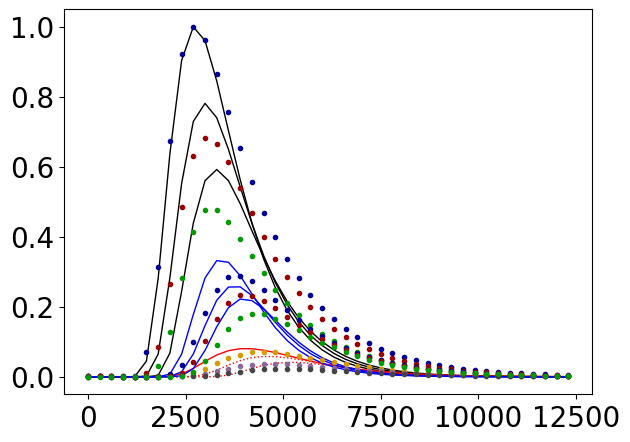

[7.36113620e-05 7.65681704e-04 3.71167028e-06 5.93108557e-07
 7.72913050e-08 4.31425467e-01 6.26995105e-02 8.10622119e-04
 6.69129920e-03 2.15842046e-08 2.42797723e-02 3.23966064e-07
 5.64125771e-04 6.06695942e-06] 799.2225969944311


np.float64(799.2225969944311)

In [25]:


mct_obj([0.23611362, 0.54267203, 0.28550771, 0.19701491, 0.61101633,
       0.42568229, 0.59908805, 0.38176369, 0.56510209, 0.77804535,
       0.6480537 , 0.50349984, 0.52793066, 0.30921901]
)


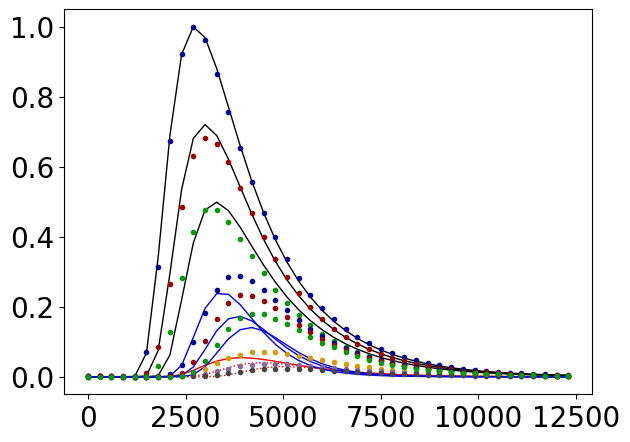

[6.67044075e-05 7.99293580e-04 3.80720347e-06 4.67611043e-07
 6.64582093e-08 5.06649805e-01 7.66476499e-02 8.69565389e-04
 8.18305414e-03 2.74638346e-08 2.58185154e-02 2.41586879e-07
 3.76992240e-05 1.45337474e-05] 138.30558699688063


KeyboardInterrupt: 

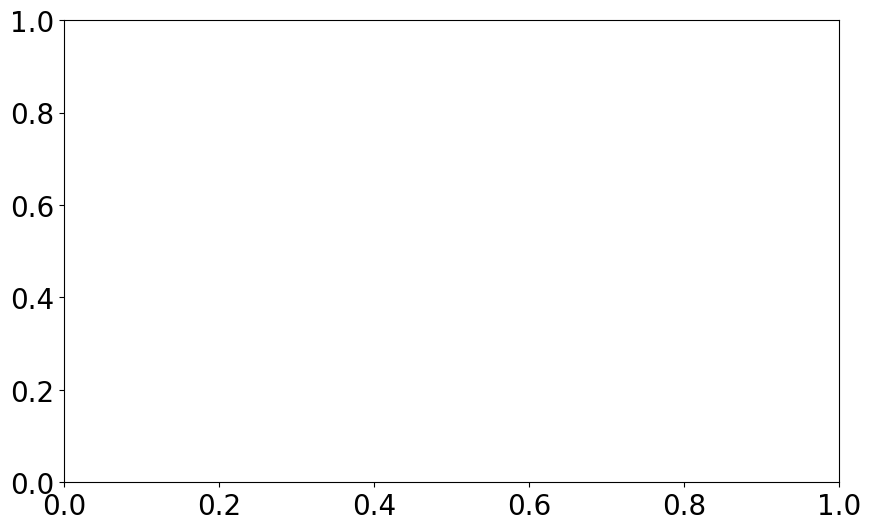

In [26]:
x0 = ([0.23611362, 0.54267203, 0.28550771, 0.19701491, 0.61101633,
       0.42568229, 0.59908805, 0.38176369, 0.56510209, 0.77804535,
       0.6480537 , 0.50349984, 0.52793066, 0.30921901])


# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm = minimize(
    fun=mct_obj,
    x0=x0,
    method='Nelder-Mead',
    bounds=(14*((0,1),)),
    options={'disp':True, 'maxiter': 2000, 'eps':1e-1, 'finite_diff_rel_step':1e-2},
    tol=1e-10)


In [ ]:
result_nm.x


array([0.17291162, 0.60701347, 0.51659728, 0.50220287, 0.13099755,
       0.49657375, 0.63559234, 0.032179  , 0.5925654 , 0.80288588,
       0.65525147, 0.38002175, 0.99995531, 0.95260008])

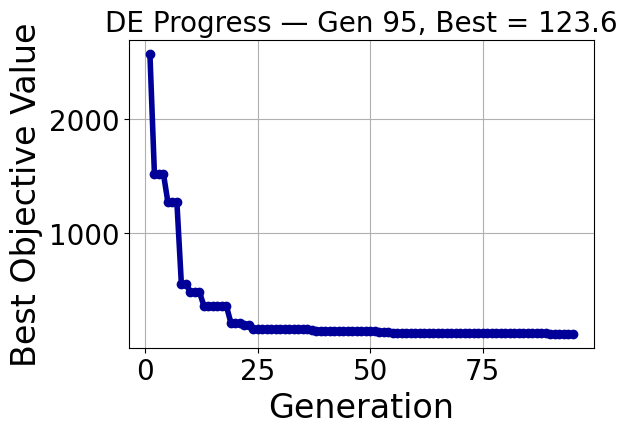

: 

In [28]:
import threading
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.optimize import differential_evolution

# ---------------- Config ----------------
TIMEOUT = 60   # seconds
PENALTY = 1e9
bounds = [(0.1, 0.9)] * 14

# ---------------- Thread-based timeout wrapper ----------------
def run_with_timeout(func, x, timeout=TIMEOUT, penalty=PENALTY):
    result_container = {"value": penalty}

    def target():
        try:
            result_container["value"] = func(x)
        except Exception:
            result_container["value"] = penalty

    thread = threading.Thread(target=target)
    thread.daemon = True
    thread.start()
    thread.join(timeout)
    return result_container["value"]

def mct_obj_safe(x):
    return run_with_timeout(mct_obj, x, timeout=TIMEOUT, penalty=PENALTY)

# ---------------- Progress tracking ----------------
best_values = []
generations = []

def callback_de(xk, convergence):
    fx = mct_obj_safe(xk)  # Evaluate current best with timeout
    best_values.append(fx)
    generations.append(len(generations) + 1)

    clear_output(wait=True)
    plt.figure(figsize=(6, 4))
    plt.plot(generations, best_values, marker="o")
    plt.title(f"DE Progress — Gen {generations[-1]}, Best = {fx:.4g}")
    plt.xlabel("Generation")
    plt.ylabel("Best Objective Value")
    plt.grid(True)
    plt.show()

    return False  # continue optimization

# ---------------- Run DE ----------------
result_de = differential_evolution(
    func=mct_obj_safe,
    bounds=bounds,
    strategy="best1bin",
    maxiter=100,        # adjust for your problem
    popsize=15,
    mutation=(0.5, 1.0),
    recombination=0.7,
    polish=False,
    workers=1,          # serial execution
    updating='deferred',
    callback=callback_de,
    disp=True
)

print("DE success:", result_de.success)
print("DE message:", result_de.message)
print("Best f:", result_de.fun)
print("Best x:", result_de.x)



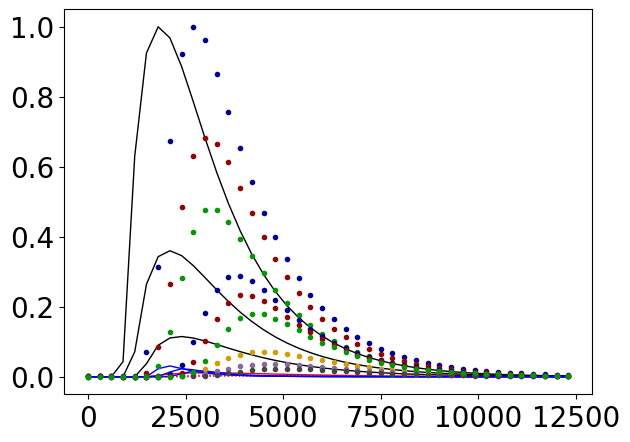

[7.60729355e-05 4.38782437e-03 9.57966222e-04 8.15018719e-04
 1.36039435e-07 4.61258553e-01 4.76861978e-02 3.00032826e-04
 9.22440818e-03 3.33443517e-08 9.71948609e-03 6.05912449e-08
 6.61567739e-05 1.94138032e-06] 9375.090395160405


In [ ]:
x0 = [0.23611362, 0.54267203, 0.28550771, 0.19701491, 0.61101633,
       0.42568229, 0.59908805, 0.38176369, 0.56510209, 0.77804535,
       0.6480537 , 0.50349984, 0.52793066, 0.30921901]

# Initialize the plot
fig, ax = plt.subplots()

fig.canvas.draw()
display.display(fig)

result_nm = minimize(
    fun=mct_obj,
    x0=x0,
    method='trust-constr',
    jac='3-point',                      # better: pass a callable analytic gradient
    bounds=14 * ((0, 1),),
    options={
        'maxiter': 2000,
        #'ftol': 1e-9,                   # function tolerance (strict)
        'gtol': 1e-8,                   # projected gradient tolerance (strict)
        #'maxls': 50,                    # more line-search steps if needed
        #'eps': 1e-6,                    # finite-diff step (small!)
        # do NOT set 'finite_diff_rel_step' at the same time as 'eps'
    }
)
print(result_nm.message)
print("iters:", result_nm.nit, "func evals:", result_nm.nfev, "grad evals:", result_nm.njev)
print("||proj grad||_inf:", float(np.abs(result_nm.jac).max()))

In [ ]:
result_nm.x

array([0.19382458, 0.60867478, 0.51125933, 0.50641393, 0.22567876,
       0.45473663, 0.61840782, 0.01866644, 0.61999013, 0.78912265,
       0.64882431, 0.40865481, 0.9988105 , 0.95275066])

In [28]:
from scipy.optimize import check_grad

def f(x): return mct_obj(x)
def g_fd(x, eps=1e-6):                      # central 3-point matches jac='3-point'
    # SciPy does this internally, but we can test magnitude
    return np.gradient([f(x + e*np.eye(len(x))[i]) for i,e in enumerate([eps]*len(x))], axis=0)  # or implement proper FD
# If you have an analytic grad g, do: check_grad(f, g, x0)


In [ ]:
best_x=[0.36266305, 0.69500574, 0.86417865, 0.7833508 , 0.63807555,
       0.19478007, 0.99885565, 0.39965948, 0.64674288, 0.38620454,
       0.82473283, 0.53655679, 0.20185294, 0.97181281, 0.75185567,
       0.70917908, 0.77614519]

In [ ]:
def plot_pretty(x_norm):

    x = denormalize_parameters(x_norm)
    
    process = setup_process(x)
    
    simulation_results = simulator.simulate(process) 
    time_new = np.arange(t[0]*60,t[-1]*60+60,60)

    mct_up = process.flow_sheet.units[2]
    mct_side1 = process.flow_sheet.units[3]
    mct_side2 = process.flow_sheet.units[4]
    mct_low = process.flow_sheet.units[5]

    lenghts_up = [x / 1000 for x in xi_up]
    lenghts_side = [x / 1000 for x in xi_side]
    lenghts_low = [x / 1000 for x in xi_low]

    eval_location1 = lenghts_up
    eval_location2_1 = lenghts_side[0:1]
    eval_location2_2 = list(np.array(lenghts_side[1:])-lenghts_side[1])
    eval_location3 = lenghts_low


    cb_mct1 = interpolate_cb_from_simulation_results(simulation_results, mct_up, time_new, axial_positions_new = eval_location1)
    calc_data_mct1 = np.sum(cb_mct1, axis=2).squeeze()
    
    cb_mct2 = interpolate_cb_from_simulation_results(simulation_results, mct_side1, time_new, axial_positions_new = eval_location2_1)
    calc_data_mct2 =   np.atleast_2d(np.sum(cb_mct2, axis=2).squeeze()).T

    cb_mct3 = interpolate_cb_from_simulation_results(simulation_results, mct_side2, time_new, axial_positions_new = eval_location2_2)
    calc_data_mct3 = np.sum(cb_mct3, axis=2).squeeze()

    cb_mct4 = interpolate_cb_from_simulation_results(simulation_results, mct_low, time_new, axial_positions_new = eval_location3)
    calc_data_mct4 = np.sum(cb_mct4, axis=2).squeeze()


    calc_data = np.hstack((calc_data_mct1,calc_data_mct2,calc_data_mct3,calc_data_mct4))
    calc_data = calc_data/np.max(calc_data)
    
    #plt.plot(t,calc_data, label="mct1", linewidth=1)
    #plt.gca().set_prop_cycle(None)
    
    plt.style.use('default')
    
    plt.xticks(fontsize=14)
    plt.yticks(fontsize=14) 
    
    plt.xlabel("Time [min]")
    plt.ylabel("Activity [a.u.]")


    plt.plot(calc_data[:,0:3], label="Upper ROI 1-3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], linewidth=1.5)
    plt.plot(calc_data[:,3:6], label="Side ROI 1-3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], linewidth=1.5)
    plt.plot(calc_data[:,6:], label="Lower ROI 1-3", color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], linewidth=1.5)
    
    plt.plot(t,exp_data[:,0:3],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][0], markersize=8)
    plt.plot(t,exp_data[:,3:6],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][1], markersize=8)
    plt.plot(t,exp_data[:,6:],'.',color=plt.rcParams['axes.prop_cycle'].by_key()['color'][2], markersize=8)

    # Remove duplicate labels
    handles, labels = plt.gca().get_legend_handles_labels()
    unique_handles_labels = dict(zip(labels, handles))  # Remove duplicates

    # Add legend with unique labels
    plt.legend(unique_handles_labels.values(), unique_handles_labels.keys(), fontsize=12)
    
    plt.xlabel("Time [min]", fontsize=20)
    plt.ylabel("Activity [a.u.]", fontsize=20)

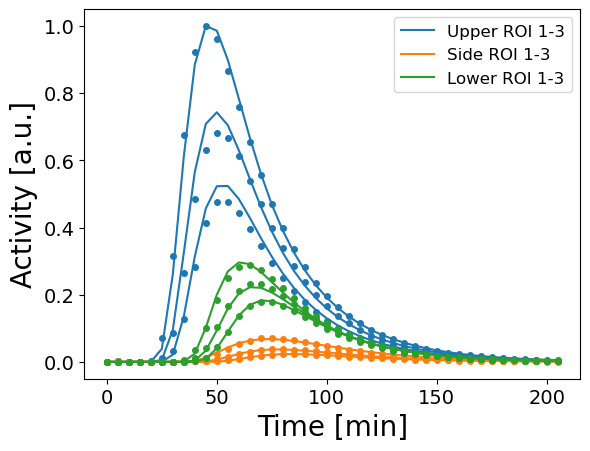

In [ ]:
plot_pretty([0.70351582, 0.59075192, 0.55176052, 0.54033419, 0.5897732 ,
       0.44253102, 0.66759524, 0.64666535, 0.70314253, 0.5932418 ,
       0.54779138, 0.46501173, 0.52519675, 0.55915639])

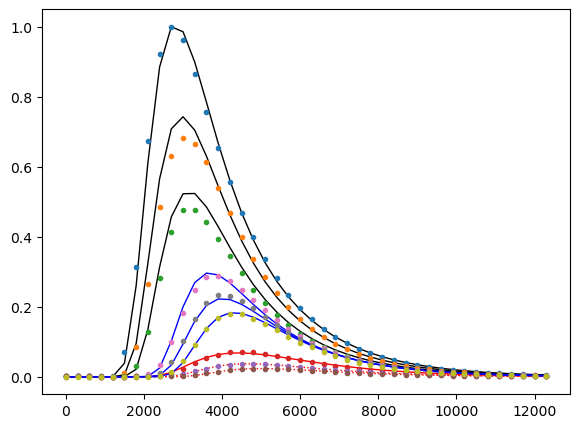

[1.20351582e-04 2.07380196e-03 9.24367526e-04 7.29470460e-04
 2.03216422e-03 4.48105710e-01 1.00643497e-01 1.71130236e-02
 3.27878281e-02 6.02178714e-09 1.33154558e-02 2.48333432e-07
 5.33053440e-04 1.07747576e-03] 3.64319106802485
Parameter 0: ±2.7233648915242163%
Parameter 1: ±0.821554399519226%
Parameter 2: ±0.3650085231723232%
Parameter 3: ±0.4841233168882854%
Parameter 4: ±0.5980293961165826%
Parameter 5: ±3.1445649541969836%
Parameter 6: ±1.3063907301181186%
Parameter 7: ±1.113373379908469%
Parameter 8: ±0.6634145835177451%
Parameter 9: ±0.9876989461667998%
Parameter 10: ±0.471388912475836%
Parameter 11: ±3.4725971109436577%
Parameter 12: ±5.681825864867334%
Parameter 13: ±3.524984779746127%


In [ ]:
x_best_fit = [0.70351582, 0.59075192, 0.55176052, 0.54033419, 0.5897732 ,
       0.44253102, 0.66759524, 0.64666535, 0.70314253, 0.5932418 ,
       0.54779138, 0.46501173, 0.52519675, 0.55915639]

def compute_jacobian(f, x, eps=None):
    """Computes numerical Jacobian using central difference with adaptive epsilon."""
    x = np.asarray(x)
    n_params = len(x)
    f_x = np.asarray(f(x)).ravel()
    n_outputs = len(f_x)
    J = np.zeros((n_outputs, n_params))

    if eps is None:
        eps = np.sqrt(np.finfo(float).eps) * np.maximum(1.0, np.abs(x))

    for i in range(n_params):
        x_step = np.zeros_like(x)
        x_step[i] = eps[i]

        f_plus = np.asarray(f(x + x_step)).ravel()
        f_minus = np.asarray(f(x - x_step)).ravel()

        J[:, i] = (f_plus - f_minus) / (2 * eps[i])

    return J



# Compute the Jacobian
J = compute_jacobian(mct_obj_res, x_best_fit)

# Step 3: Compute the covariance matrix
JTJ_inv = np.linalg.pinv(J.T @ J)
sigma_squared = np.var(mct_obj_res(x_best_fit))  # Estimate variance of residuals
C = JTJ_inv * sigma_squared  # Covariance matrix

# Step 4: Compute parameter uncertainties
param_uncertainties = np.sqrt(np.abs(np.diag(C)))  # Extract uncertainties
rel_param_uncertanties = param_uncertainties / np.abs(x_best_fit)

# Print results
for i, uncertainty in enumerate(rel_param_uncertanties):
    print(f"Parameter {i}: ±{uncertainty*100}%")

In [ ]:
calc = return_calc_data([0.70351582, 0.59075192, 0.55176052, 0.54033419, 0.5897732 ,
       0.44253102, 0.66759524, 0.64666535, 0.70314253, 0.5932418 ,
       0.54779138, 0.46501173, 0.52519675, 0.55915639])

In [ ]:
calc.shape

(206, 9)

t_ci shape: (3, 3)
Velocities (m/s): [np.float64(0.0001047637401460212), np.float64(6.753432650988623e-05), np.float64(5.957017887823315e-05)]
Velocities (mm/min): [np.float64(6.285824408761272), np.float64(4.052059590593174), np.float64(3.574210732693989)]
Relative errors (fraction): [np.float64(0.029843031999024522), np.float64(0.07881228744844905), np.float64(0.057622802372404525)]
Relative errors (%): [np.float64(2.984303199902452), np.float64(7.881228744844905), np.float64(5.762280237240453)]


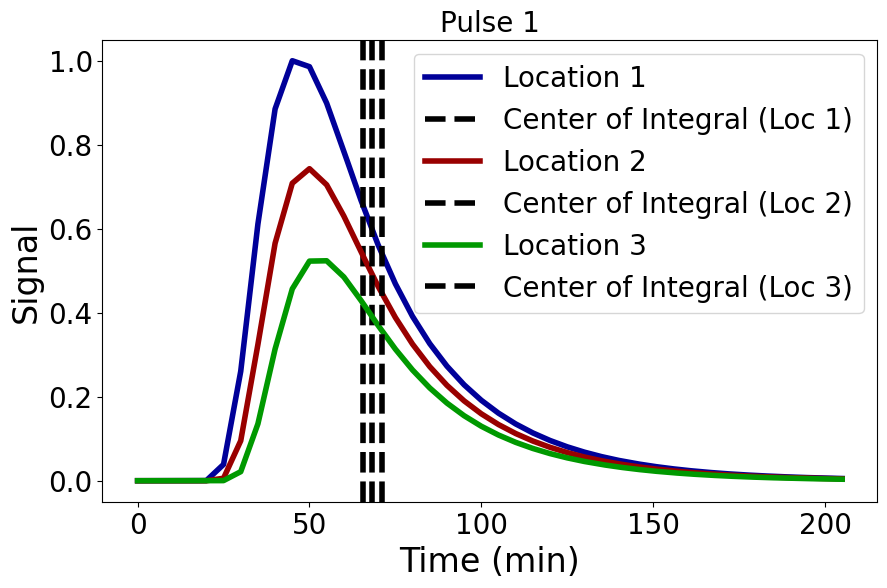

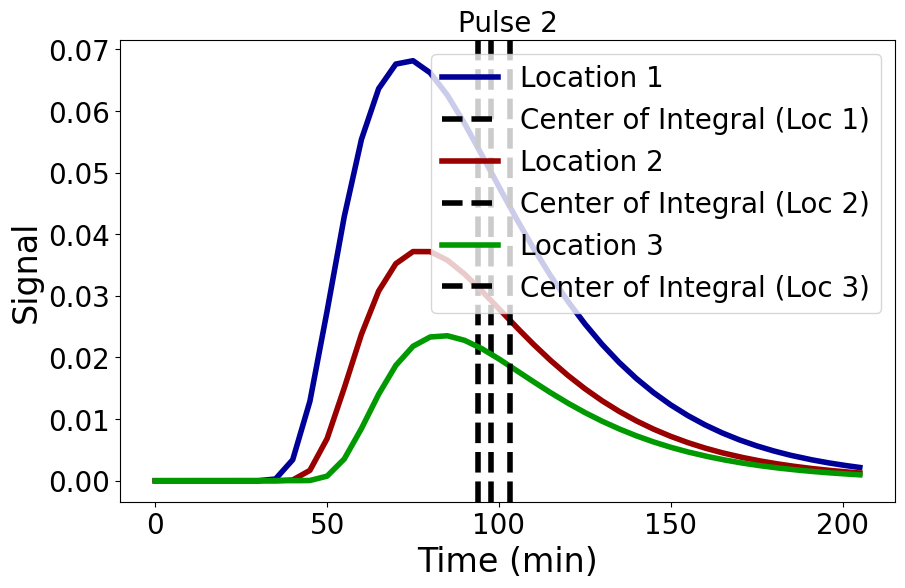

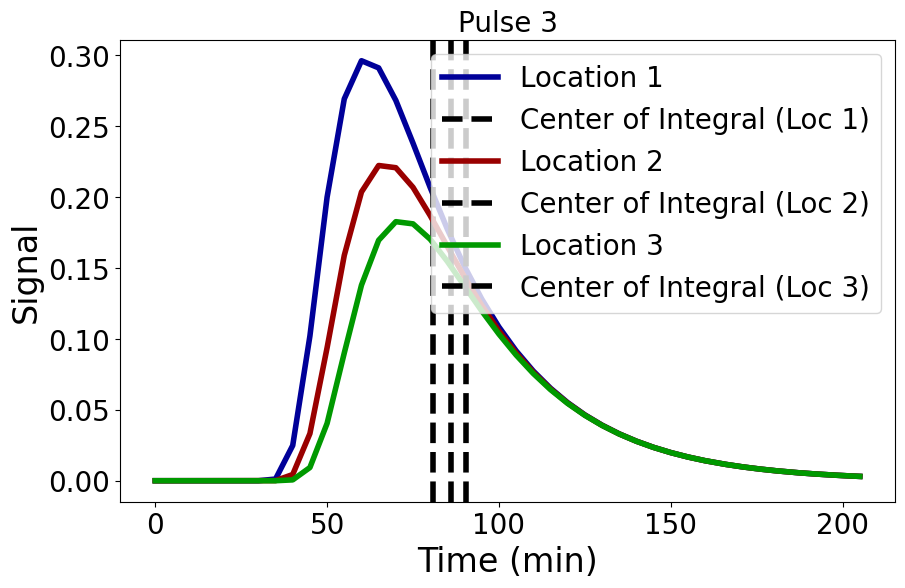

In [ ]:
n_times = 206
t_50int = np.linspace(0, 60*t[-1], n_times)  # 205 minutes → seconds

# Reshape data
signals = calc.reshape(n_times, 3, 3)
signals = signals.transpose(0, 2, 1)

# Compute center of integral
t_ci = np.sum(t_50int[:, None, None] * signals, axis=0) / np.sum(signals, axis=0)
print("t_ci shape:", t_ci.shape)

xi_list = np.array([xi_up, xi_side, xi_low])/1000
# Fit for each pulse
velocities = []
velocity_errors = []

for i in range(3):
    x_i = xi_list[i]
    t_i = t_ci[:, i]

    # Fit line AND get covariance
    coeffs, cov = np.polyfit(t_i, x_i, 1, cov=True)
    v = coeffs[0]
    velocities.append(v)

    SE = np.sqrt(cov[0,0])
    rel_error = SE / abs(v)
    velocity_errors.append(rel_error)

print("Velocities (m/s):", velocities)
print("Velocities (mm/min):", [v * 60000 for v in velocities])
print("Relative errors (fraction):", velocity_errors)
print("Relative errors (%):", [100 * e for e in velocity_errors])


for pulse_idx in range(3):
    plt.figure(figsize=(10, 6))
    for loc_idx in range(3):
        plt.plot(t_50int / 60, signals[:, loc_idx, pulse_idx], label=f'Location {loc_idx+1}')
        # Draw vertical line for t_ci for this location
        plt.axvline(t_ci[loc_idx, pulse_idx] / 60,
                    color='k', linestyle='--',
                    label=f'Center of Integral (Loc {loc_idx+1})')
    plt.title(f'Pulse {pulse_idx+1}')
    plt.xlabel('Time (min)')
    plt.ylabel('Signal')
    plt.legend()
    plt.show()

In [ ]:
t_50int.shape

(206,)

In [ ]:
t[-1]

np.float64(205.0)

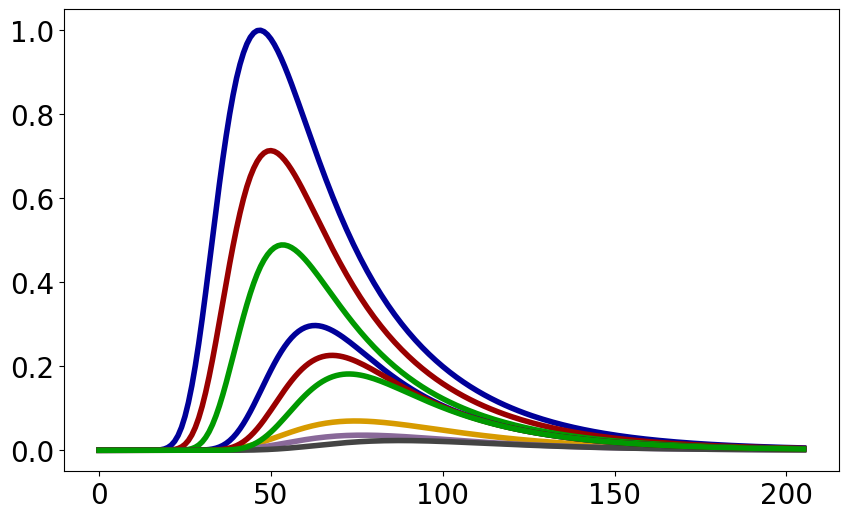

In [ ]:
plt.plot(calc)